# CO_drift_diagnostic

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QuantLet/Conformal_Oracle/blob/main/CO_drift_diagnostic/CO_drift_diagnostic.ipynb)

**Distributional drift diagnostic via empirical total variation distance on rolling conformal scores**

Published in: *Calibrating the Oracle — Distribution-Free Conformal Risk Measures for LLM-Based Financial Forecasting*

Section: §3.2.3 — Rolling Coverage Guarantee (Proposition 3.2)

In [1]:
# Install dependencies (if running on Google Colab)
import sys
if 'google.colab' in sys.modules:
    !pip install -q numpy pandas matplotlib scipy pyarrow

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import ks_2samp
from pathlib import Path

In [3]:
# ── Configuration ──
ALPHA = 0.01
W = 250              # rolling window size (as in paper)
F_CAL = 0.70         # calibration fraction
DATA_DIR = Path('../cfp_ijf_data')
OUT_DIR = Path('.')

In [4]:
# ── Load data ──
returns = pd.read_csv(DATA_DIR / 'returns' / 'SP500.csv',
                      index_col=0, parse_dates=True)
forecasts = pd.read_parquet(DATA_DIR / 'lagllama' / 'SP500.parquet')

# Align dates
common_idx = returns.index.intersection(forecasts.index)
r = returns.loc[common_idx, 'log_return']
var_01 = forecasts.loc[common_idx, 'VaR_0.01']

print(f'Aligned series: {len(r)} observations')
print(f'Date range: {r.index[0].date()} to {r.index[-1].date()}')

Aligned series: 6078 observations
Date range: 2002-01-22 to 2026-03-18


In [5]:
# ── Conformity scores: S_t = q̂_t^lo - r_t ──
scores = var_01.values - r.values
dates = r.index

print(f'Score statistics:')
print(f'  Mean:   {np.mean(scores):.6f}')
print(f'  Std:    {np.std(scores):.6f}')
print(f'  Min:    {np.min(scores):.6f}')
print(f'  Max:    {np.max(scores):.6f}')

Score statistics:
  Mean:   -0.024785
  Std:    0.020694
  Min:    -0.340334
  Max:    0.074545


In [6]:
def empirical_tv(x, y, n_bins=None):
    """Empirical total variation distance via histogram binning."""
    if n_bins is None:
        n_bins = int(np.sqrt(len(x) + len(y)))
    all_vals = np.concatenate([x, y])
    bins = np.linspace(all_vals.min(), all_vals.max(), n_bins + 1)
    p1, _ = np.histogram(x, bins=bins, density=True)
    p2, _ = np.histogram(y, bins=bins, density=True)
    bin_width = bins[1] - bins[0]
    return 0.5 * np.sum(np.abs(p1 - p2)) * bin_width

In [7]:
# ── Compute δ̂_w(t) via empirical TV and KS test ──
# Proposition 3.2 is stated in TV distance, so we estimate TV directly
# using sqrt(w) histogram bins. KS p-values are retained as a
# complementary significance test.

n = len(scores)
n_bins = int(np.sqrt(W))  # ~16 bins for w=250
delta_hat_tv = np.full(n, np.nan)
ks_pvals = np.full(n, np.nan)

for t in range(W, n):
    window = scores[t - W : t]
    half = W // 2
    first_half = window[:half]
    second_half = window[half:]
    delta_hat_tv[t] = empirical_tv(first_half, second_half, n_bins=n_bins)
    _, pval = ks_2samp(first_half, second_half)
    ks_pvals[t] = pval

drift_dates = dates[W:]
drift_vals = delta_hat_tv[W:]
drift_pvals = ks_pvals[W:]

print(f'Drift diagnostic computed for {len(drift_vals)} windows ({n_bins} bins)')
print(f'  Mean \u03b4\u0302_w(t):   {np.nanmean(drift_vals):.4f}')
print(f'  Max  \u03b4\u0302_w(t):   {np.nanmax(drift_vals):.4f}')
print(f'  Windows with KS p < 0.05: {np.sum(drift_pvals < 0.05)} / {len(drift_pvals)} '
      f'({100*np.mean(drift_pvals < 0.05):.1f}%)')

Drift diagnostic computed for 5828 windows (15 bins)
  Mean δ̂_w(t):   0.2342
  Max  δ̂_w(t):   0.6160
  Windows with KS p < 0.05: 3494 / 5828 (60.0%)


In [8]:
# ── Key events ──
events = {
    'GFC':       ('2008-09-15', '2009-03-09'),
    'COVID-19':  ('2020-02-20', '2020-04-30'),
    'SVB':       ('2023-03-08', '2023-03-20'),
}

# Peak drift around COVID
covid_mask = (drift_dates >= '2020-02-01') & (drift_dates <= '2020-06-30')
if covid_mask.any():
    peak_idx = np.argmax(drift_vals[covid_mask])
    peak_date = drift_dates[covid_mask][peak_idx]
    peak_val = drift_vals[covid_mask][peak_idx]
    print(f'Peak drift around COVID: \u03b4\u0302 = {peak_val:.4f} on {peak_date.date()}')

Peak drift around COVID: δ̂ = 0.4160 on 2020-06-30


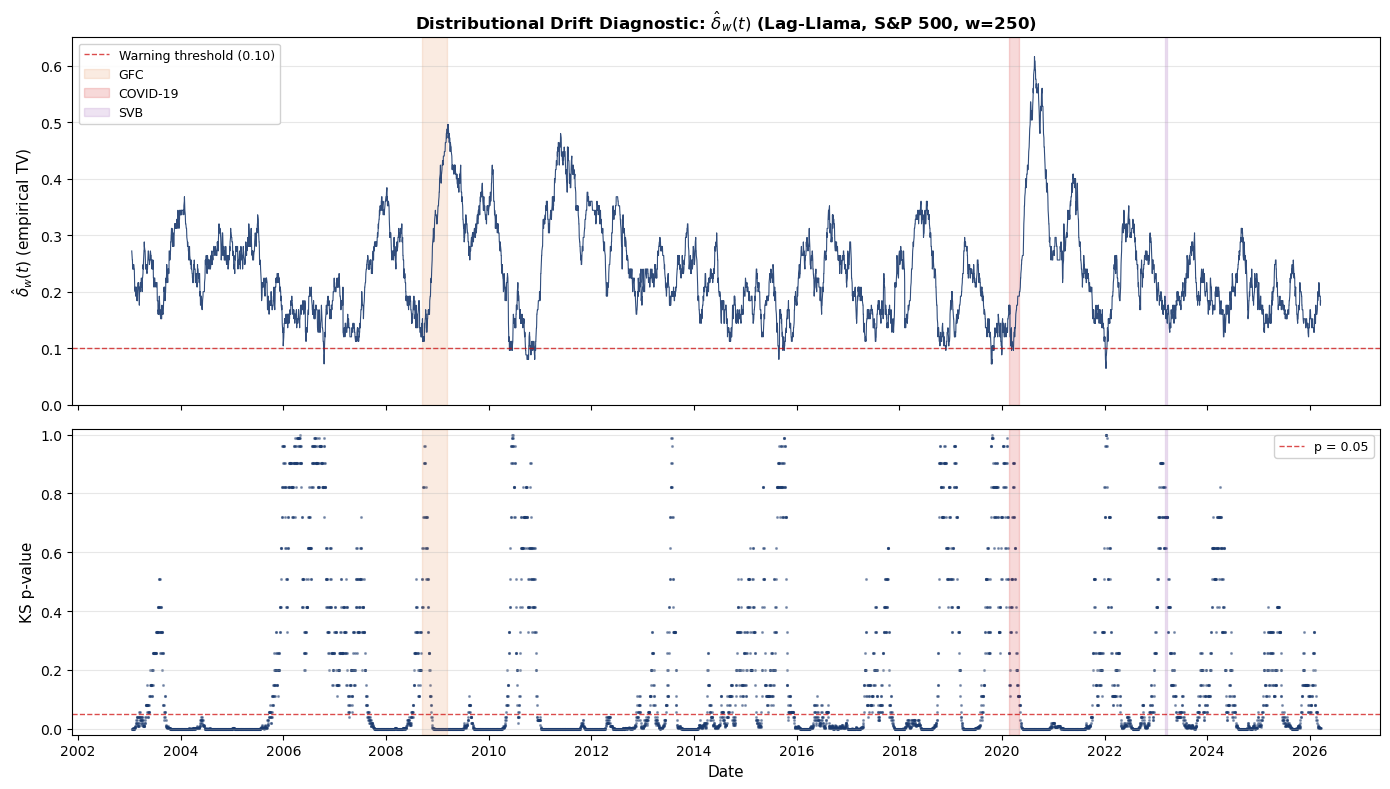

Saved: fig_drift_diagnostic.pdf, fig_drift_diagnostic.png


In [9]:
# ── Figure: Drift diagnostic ──
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8),
                                gridspec_kw={'height_ratios': [1.2, 1]},
                                sharex=True)

# --- Panel A: empirical TV distance ---
ax1.plot(drift_dates, drift_vals, color='#1A3A6E', lw=0.8, alpha=0.9)
ax1.axhline(0.10, color='#CD0000', ls='--', lw=1.0, alpha=0.7,
            label='Warning threshold (0.10)')

colors_ev = {'GFC': '#E07B39', 'COVID-19': '#CD0000', 'SVB': '#8E44AD'}
for name, (start, end) in events.items():
    ax1.axvspan(pd.Timestamp(start), pd.Timestamp(end),
               alpha=0.15, color=colors_ev[name], label=name)

ax1.set_ylabel(r'$\hat{\delta}_w(t)$ (empirical TV)', fontsize=11)
ax1.set_title(r'Distributional Drift Diagnostic: $\hat{\delta}_w(t)$ '
              f'(Lag-Llama, S&P 500, w={W})', fontweight='bold', fontsize=12)
ax1.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax1.set_ylim(0, min(0.65, np.nanmax(drift_vals) * 1.15))
ax1.grid(axis='y', alpha=0.3)

# --- Panel B: KS p-value ---
ax2.scatter(drift_dates, drift_pvals, s=1.5, c='#1A3A6E', alpha=0.4)
ax2.axhline(0.05, color='#CD0000', ls='--', lw=1.0, alpha=0.7,
            label='p = 0.05')
for name, (start, end) in events.items():
    ax2.axvspan(pd.Timestamp(start), pd.Timestamp(end),
               alpha=0.15, color=colors_ev[name])

ax2.set_ylabel('KS p-value', fontsize=11)
ax2.set_xlabel('Date', fontsize=11)
ax2.set_ylim(-0.02, 1.02)
ax2.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax2.grid(axis='y', alpha=0.3)

ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
fig.savefig(OUT_DIR / 'fig_drift_diagnostic.pdf', bbox_inches='tight', dpi=300)
fig.savefig(OUT_DIR / 'fig_drift_diagnostic.png', bbox_inches='tight', dpi=300)
plt.show()
print('Saved: fig_drift_diagnostic.pdf, fig_drift_diagnostic.png')

In [10]:
# ── Summary statistics by regime ──
regimes = {
    'Full sample':  (drift_dates[0], drift_dates[-1]),
    'Pre-GFC':      ('2003-01-01', '2008-09-14'),
    'GFC':          ('2008-09-15', '2009-03-09'),
    'Post-GFC calm': ('2013-01-01', '2019-12-31'),
    'COVID-19':     ('2020-02-20', '2020-04-30'),
    'Post-COVID':   ('2021-01-01', '2023-01-01'),
    'SVB crisis':   ('2023-03-08', '2023-03-31'),
}

print(f'{"Regime":<20s} {"Mean \u03b4\u0302":>10s} {"Max \u03b4\u0302":>10s} {"KS p<.05":>10s} {"N":>6s}')
print('-' * 60)
for name, (s, e) in regimes.items():
    mask = (drift_dates >= pd.Timestamp(s)) & (drift_dates <= pd.Timestamp(e))
    if mask.any():
        vals = drift_vals[mask]
        pvals = drift_pvals[mask]
        print(f'{name:<20s} {np.mean(vals):10.4f} {np.max(vals):10.4f} '
              f'{100*np.mean(pvals < 0.05):9.1f}% {len(vals):6d}')

Regime                  Mean δ̂     Max δ̂   KS p<.05      N
------------------------------------------------------------
Full sample              0.2342     0.6160      60.0%   5828
Pre-GFC                  0.2237     0.3840      56.3%   1424
GFC                      0.2887     0.4800      61.2%    121
Post-GFC calm            0.2064     0.3600      56.2%   1762
COVID-19                 0.1429     0.1920       0.0%     50
Post-COVID               0.2486     0.4080      66.0%    503
SVB crisis               0.1649     0.1840       0.0%     18


In [11]:
# ── Implication for coverage bound ──
# From Proposition 3.2: coverage >= 1 - alpha - delta_w(t) - Delta_w
# where Delta_w = O(sqrt(log(w)/w))

Delta_w = np.sqrt(np.log(W) / W)
print(f'Theoretical parameters (w = {W}):')
print(f'  \u0394_w (\u03b2-mixing remainder): {Delta_w:.4f}')
print(f'  \u03b1 = {ALPHA}')
print()

calm_delta = np.nanmean(drift_vals[(drift_dates >= '2013-01-01') & 
                                    (drift_dates <= '2019-12-31')])
covid_delta = np.nanmax(drift_vals[(drift_dates >= '2020-02-01') & 
                                    (drift_dates <= '2020-06-30')])

print(f'Coverage lower bound (calm, \u03b4\u0302 \u2248 {calm_delta:.3f}):')
print(f'  >= 1 - {ALPHA} - {calm_delta:.3f} - {Delta_w:.3f} = '
      f'{1 - ALPHA - calm_delta - Delta_w:.3f} ({100*(1 - ALPHA - calm_delta - Delta_w):.1f}%)')
print()
print(f'Coverage lower bound (COVID peak, \u03b4\u0302 \u2248 {covid_delta:.3f}):')
print(f'  >= 1 - {ALPHA} - {covid_delta:.3f} - {Delta_w:.3f} = '
      f'{1 - ALPHA - covid_delta - Delta_w:.3f} ({100*(1 - ALPHA - covid_delta - Delta_w):.1f}%)')
print()
print('Empirical rolling coverage from Table 5: 99.1% >> theoretical bound,')
print('confirming the bound is conservative but informative about regime shifts.')

Theoretical parameters (w = 250):
  Δ_w (β-mixing remainder): 0.1486
  α = 0.01

Coverage lower bound (calm, δ̂ ≈ 0.206):
  >= 1 - 0.01 - 0.206 - 0.149 = 0.635 (63.5%)

Coverage lower bound (COVID peak, δ̂ ≈ 0.416):
  >= 1 - 0.01 - 0.416 - 0.149 = 0.425 (42.5%)

Empirical rolling coverage from Table 5: 99.1% >> theoretical bound,
confirming the bound is conservative but informative about regime shifts.
